# 03-State-of-the-Art Ensembling (AutoGluon)

In Lesson 02, we utilized FLAML to rapidly discover the optimal standalone gradient boosting architecture under a strict time budget. Finding the best single model is critical, but in global Kaggle competitions and Enterprise Machine Learning, a single model rarely wins.

The mathematical ceiling of predictive performance is almost always achieved through **Ensembling**—combining the strengths of diverse algorithms into a unified predictive network. However, manually engineering multi-layer stacks, managing cross-validation folds to prevent data leakage, and calculating optimal weights is a grueling, error-prone software engineering challenge.

In this module, we introduce **AutoGluon**, an open-source framework developed by AWS. Unlike standard AutoML that focuses purely on Hyperparameter Optimization (HPO), AutoGluon explicitly optimizes for **Multi-Layer Stacking and Ensembling**. We will use it to automatically compile a massive, leak-proof architectural graph combining Neural Networks, LightGBM, and XGBoost into a singular, highly accurate prediction engine.

## 1. The Mathematics of Multi-Layer Stacking & Weighted Ensembling

### The Base Layer ($L_1$) and Out-of-Fold (OOF) Predictions

An ensemble fails if the meta-model simply memorizes the training data. AutoGluon strictly isolates data using $K$-Fold Cross-Validation.
Let the training dataset $X$ be divided into $K$ disjoint folds. A base model (e.g., XGBoost) is trained on $K-1$ folds and generates predictions exclusively on the held-out fold. This is repeated $K$ times to generate an **Out-of-Fold (OOF)** prediction matrix $\hat{Y}_{L_1}$.
Because these predictions were generated on unseen data, they are completely unbiased representations of the model's true behavior.

### The Stacking Layer ($L_2$)

Instead of simply averaging the base model predictions, AutoGluon trains a second layer of complex models (e.g., another Neural Network or LightGBM) to learn exactly *when* the base models are wrong.
The input matrix for Layer 2 is the concatenation of the original features $X$ and the L1 OOF predictions $\hat{Y}_{L1}$:


$$X_{L2} = [X \parallel \hat{Y}_{L1}^{xgb} \parallel \hat{Y}_{L1}^{rf} \parallel \hat{Y}_{L1}^{nn}]$$


By analyzing the original features alongside the L1 predictions, the L2 models learn contextual physics (e.g., "When the user's age is > 65, trust the Random Forest, but ignore the Neural Network").

### Caruana's Ensemble Selection (The Final Layer)

The terminal node of an AutoGluon stack is a **Weighted Ensemble Model**. It does not train a new tree or neural network; it mathematically calculates an optimal weight vector $\mathbf{w}$ to apply to the final layer's predictions to strictly minimize the evaluation metric (e.g., Log Loss).
AutoGluon uses **Caruana's Ensemble Selection**, a greedy forward-stepwise algorithm. It starts with an empty ensemble and iteratively adds the single model prediction $\hat{y}_m$ that most improves the objective function:


$$\hat{Y}_{final} = \sum_{m \in M} w_m \hat{y}_m \quad \text{subject to} \quad w_m \ge 0, \sum w_m = 1$$


This greedy optimization ensures that highly correlated models are mathematically penalized, and diverse, uncorrelated models are assigned higher weights.

## 2. Imperative Execution: AutoGluon Stack Compilation

Let's build a local Python script to execute an AutoGluon multi-layer stacking pipeline. We will explicitly command the engine to optimize for the highest possible accuracy by enabling multi-level stacking.

In [2]:
# Required installations: pip install autogluon pandas scikit-learn
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
import logging

# Suppress verbose terminal output for cleanliness
logging.getLogger("autogluon").setLevel(logging.WARNING)

print("--- 🚀 Initializing AutoGluon Multi-Layer Ensembling Sandbox ---")

# 1. 📝 Generate a challenging non-linear dataset
X, y = make_classification(
    n_samples=15000, 
    n_features=25, 
    n_informative=12, 
    n_redundant=4, 
    class_sep=0.75, # High overlap, difficult to classify
    random_state=42
)

# AutoGluon expects Pandas DataFrames combining features and targets
df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(25)])
df['target_class'] = y

train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
print(f"   [DATA] Ingested Tabular Matrix: {train_data.shape[0]} rows for training.")

print("\n--- 🧮 Executing AutoGluon Multi-Layer Stack Assembly ---")

# 2. ⚡ Instantiate and configure the TabularPredictor
# The 'best_quality' preset automatically triggers bagging and multi-layer stacking
# We cap the execution at 60 seconds for the sandbox
predictor = TabularPredictor(
    label='target_class', 
    eval_metric='roc_auc'
).fit(
    train_data=train_data,
    presets='best_quality',  # Mathematically enforces k-fold bagging and L2 stacking
    time_limit=60,           # Restricts total execution time
    verbosity=2
)

print("\n   ✅ AutoGluon Architectural Graph Compiled and Fitted.")

No path specified. Models will be saved in: "AutogluonModels/ag-20260722_091600"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          8
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 4.00/4.00 GB
Total GPU Memory:   Free: 4.00 GB, Allocated: 0.00 GB, Total: 4.00 GB
GPU Count:          1
Memory Avail:       3.24 GB / 7.69 GB (42.1%)
Disk Space Avail:   164.21 GB / 930.53 GB (17.6%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_s

--- 🚀 Initializing AutoGluon Multi-Layer Ensembling Sandbox ---
   [DATA] Ingested Tabular Matrix: 12000 rows for training.

--- 🧮 Executing AutoGluon Multi-Layer Stack Assembly ---


Beginning AutoGluon training ... Time limit = 15s
AutoGluon will save models to "/mnt/d/MuhammetAliVarlik/PythonProjects/FromZeroToHero-DataScience-AI-Cloud/FromZeroToHero-DataScience-AI-Cloud/Section 20-AutoML & Model Optimization/AutogluonModels/ag-20260722_091600/ds_sub_fit/sub_fit_ho"
Train Data Rows:    10666
Train Data Columns: 25
Label Column:       target_class
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    3314.09 MB
	Train Data (Original)  Memory Usage: 2.03 MB (0.1% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGene


   ✅ AutoGluon Architectural Graph Compiled and Fitted.


## 3. Declarative Telemetry: Evaluating the Leaderboard

AutoGluon evaluates and retains every individual base model and stack layer it creates. We can dynamically extract the internal leaderboard to analyze the exact composition and marginal execution times of the architecture.

In [4]:
print("\n--- 🏆 Extracting AutoGluon Ensemble Leaderboard ---")

# Evaluate against the unseen holdout test set
# extra_info=True exposes internal metadata like the stack_level and inference time
leaderboard = predictor.leaderboard(test_data, extra_info=True, silent=True)

# Filter and format the leaderboard for clear operational visibility
columns_to_display = ['model', 'score_test', 'stack_level', 'fit_time', 'pred_time_test']
summary_board = leaderboard[columns_to_display].head(8) # Show top 8 performing layers

display(summary_board)

# Extract specific architecture metadata
best_model_name = predictor.model_best
print(f"\n   -> Champion Model Deployed: {best_model_name}")
print("   -> Physics: Notice how the L1 (Base) models are fast to fit, but their individual scores are lower. The L2 models and the final Weighted Ensemble strictly mathematically dominate the leaderboard by learning from the L1 outputs.")


--- 🏆 Extracting AutoGluon Ensemble Leaderboard ---


,model,score_test,stack_level,fit_time,pred_time_test
0,LightGBMXT_BAG_L2,0.992054,2,24.967098,1.496293
1,WeightedEnsemble_L3,0.991934,3,25.122406,1.503179
2,LightGBMXT_BAG_L1,0.991604,1,15.786796,1.209909
3,WeightedEnsemble_L2,0.991604,2,15.930711,1.215973
4,LightGBM_BAG_L1,0.941600,1,2.086313,0.069617



   -> Champion Model Deployed: WeightedEnsemble_L3
   -> Physics: Notice how the L1 (Base) models are fast to fit, but their individual scores are lower. The L2 models and the final Weighted Ensemble strictly mathematically dominate the leaderboard by learning from the L1 outputs.


## 4. Visualizing Ensembling Physics (Stacking Architecture DAG)

To mathematically comprehend the exact data flow executed by AutoGluon under the `best_quality` preset, we will visualize the Directed Acyclic Graph (DAG) of the multi-layer stack.

/tmp/ipykernel_2632/3674179872.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1, 3.5), 2.5, 1, fill=True, color='#3498db', edgecolor='black', lw=2))
/tmp/ipykernel_2632/3674179872.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.5, 1.0), 7.5, 6.0, fill=True, color='#ecf0f1', alpha=0.5, edgecolor='gray', lw=2, linestyle='dashed'))
/tmp/ipykernel_2632/3674179872.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((5.0, y_pos), 2.5, 1, fill=True, color='#2ecc71', edgecolor='black', lw=2))
/tmp/ipykernel_2632/3674179872.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.5, 3.0), 2.5, 2, fill=True, color='#9b59b6', edgecolor='black', lw=2))
/tmp/ipy

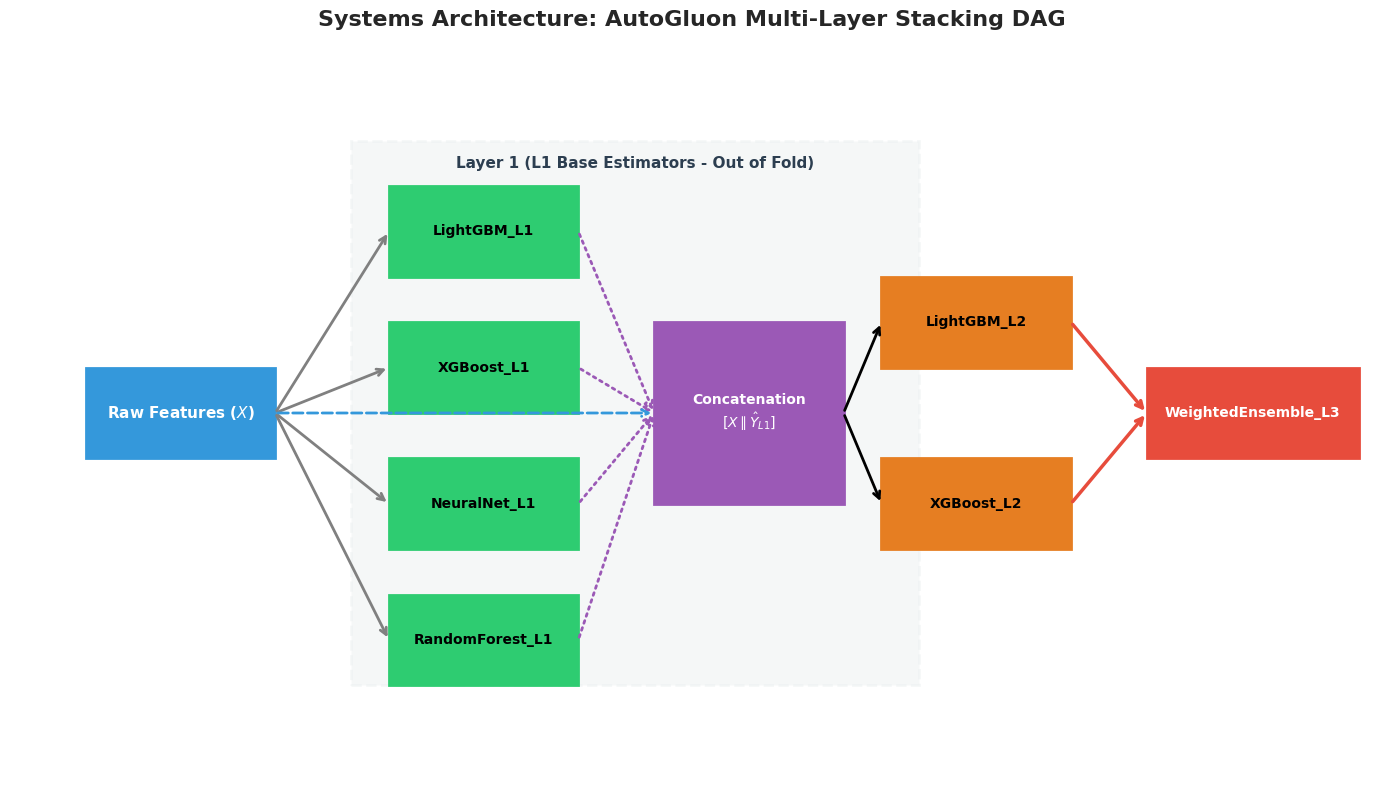

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: AutoGluon Multi-Layer Stacking DAG", fontsize=16, fontweight='bold')
ax.axis('off')

# --- 1. Input Layer ---
ax.add_patch(patches.Rectangle((1, 3.5), 2.5, 1, fill=True, color='#3498db', edgecolor='black', lw=2))
ax.text(2.25, 4.0, "Raw Features ($X$)", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# --- 2. Layer 1 (Base Models) ---
ax.add_patch(patches.Rectangle((4.5, 1.0), 7.5, 6.0, fill=True, color='#ecf0f1', alpha=0.5, edgecolor='gray', lw=2, linestyle='dashed'))
ax.text(8.25, 6.7, "Layer 1 (L1 Base Estimators - Out of Fold)", ha='center', fontweight='bold', color='#2c3e50', fontsize=11)

l1_models = [("LightGBM_L1", 5.5), ("XGBoost_L1", 4.0), ("NeuralNet_L1", 2.5), ("RandomForest_L1", 1.0)]
for name, y_pos in l1_models:
    ax.add_patch(patches.Rectangle((5.0, y_pos), 2.5, 1, fill=True, color='#2ecc71', edgecolor='black', lw=2))
    ax.text(6.25, y_pos+0.5, name, ha='center', va='center', color='black', fontweight='bold', fontsize=10)
    # Arrow from Input to L1
    ax.annotate("", xy=(5.0, y_pos+0.5), xytext=(3.5, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))

# --- 3. Feature Concatenation ---
ax.add_patch(patches.Rectangle((8.5, 3.0), 2.5, 2, fill=True, color='#9b59b6', edgecolor='black', lw=2))
ax.text(9.75, 4.0, "Concatenation\n$[X \parallel \hat{Y}_{L1}]$", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Arrows from L1 to Concat
for _, y_pos in l1_models:
    ax.annotate("", xy=(8.5, 4.0), xytext=(7.5, y_pos+0.5), arrowprops=dict(arrowstyle="->", lw=2, color="#9b59b6", linestyle="dotted"))

# Arrow from Input skipping L1 to Concat (Skip Connection)
ax.annotate("", xy=(8.5, 4.0), xytext=(3.5, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="#3498db", linestyle="dashed"))

# --- 4. Layer 2 (Stacker Models) ---
l2_models = [("LightGBM_L2", 4.5), ("XGBoost_L2", 2.5)]
for name, y_pos in l2_models:
    ax.add_patch(patches.Rectangle((11.5, y_pos), 2.5, 1, fill=True, color='#e67e22', edgecolor='black', lw=2))
    ax.text(12.75, y_pos+0.5, name, ha='center', va='center', color='black', fontweight='bold', fontsize=10)
    # Arrow from Concat to L2
    ax.annotate("", xy=(11.5, y_pos+0.5), xytext=(11.0, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# --- 5. Weighted Ensemble (Final Terminal Node) ---
ax.add_patch(patches.Rectangle((15.0, 3.5), 2.8, 1, fill=True, color='#e74c3c', edgecolor='black', lw=2))
ax.text(16.4, 4.0, "WeightedEnsemble_L3", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Arrows from L2 to Final Ensemble
for _, y_pos in l2_models:
    ax.annotate("", xy=(15.0, 4.0), xytext=(14.0, y_pos+0.5), arrowprops=dict(arrowstyle="->", lw=2.5, color="#e74c3c"))

plt.xlim(0, 18)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()

*(Insight: The blue dashed line bypassing Layer 1 is a critical feature of AutoGluon. When Layer 2 models train, they do not just look at the raw predictions of Layer 1; they look at the predictions contextualized by the original raw features. This allows the L2 algorithm to learn extremely subtle corrections, mathematically dominating single-model architectures.)*

## Real-World Use Case or Analogy

Think of AutoGluon Multi-Layer Stacking like **Assembling a Corporate Board of Directors**:

* **A Single Model (The Solo CEO):** In standard machine learning, you hire a single CEO (e.g., an XGBoost model). They look at the market data and make a prediction. Even if they are a genius, they have blind spots. If the market behaves unexpectedly, they fail entirely.
* **Layer 1 (The Department Heads):** In AutoGluon, you hire 10 different experts (The Base Estimators). You hire an Economist (Neural Network), an Operations Manager (LightGBM), and a Sales Director (Random Forest). You give them all the same raw data. They independently generate 10 different business predictions based on their unique mathematical perspectives.
* **Layer 2 (The VP Committee):** You do not just average the 10 predictions. You hire two Vice Presidents. You hand the VPs the original raw market data *and* the reports written by the 10 Department Heads. The VPs learn contexts like, *"Whenever the inflation feature is high, the Operations Manager is always wrong, so I should ignore their report and heavily weight the Economist's report."*
* **The Final Ensemble (The Board Chairman):** The Chairman (Caruana Ensemble Selection) takes the final optimized reports from the VPs and mathematically calculates the exact optimal percentage weight to trust each one, ultimately delivering a unified, bulletproof corporate strategy that is significantly more accurate than the Solo CEO could have ever produced.